# Name: Humza Ahmed
# Ref ID: TC-INT-1899-1230-791
# Internship Domain: Machine Learning 
# Teyzix Core Internship (June Batch 2026)

# Task 1: Customer Behavior Analytics & Churn Prediction Dashboard


# 1: Import Libraries

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, 
                             classification_report, roc_curve)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# 2: Load & Clean Data

In [15]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

for idx in df[df['TotalCharges'].isnull()].index:
    tenure = df.loc[idx, 'tenure']
    monthly = df.loc[idx, 'MonthlyCharges']
    df.loc[idx, 'TotalCharges'] = monthly if tenure == 0 else monthly * tenure

binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

print(f"Dataset loaded: {df.shape}")
print(f"Churn rate: {df['Churn'].mean():.2%}")

Dataset loaded: (7043, 21)
Churn rate: 26.54%


# 3: Feature Engineering

In [16]:
df_features = df.copy()

service_cols = ['PhoneService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in service_cols:
    df_features[col + '_num'] = df_features[col].map({
        'Yes': 1, 'No': 0, 'No internet service': 0, 'No phone service': 0
    })

df_features['TotalServices'] = df_features[['PhoneService_num', 'OnlineSecurity_num', 
                                            'OnlineBackup_num', 'DeviceProtection_num',
                                            'TechSupport_num', 'StreamingTV_num', 
                                            'StreamingMovies_num']].sum(axis=1)

df_features['TenureGroup'] = pd.cut(df_features['tenure'], 
                                    bins=[0, 12, 24, 48, 72], 
                                    labels=['0-1yr', '1-2yr', '2-4yr', '4+yr'])
df_features['IsNewCustomer'] = (df_features['tenure'] <= 12).astype(int)
df_features['IsLongTermCustomer'] = (df_features['tenure'] >= 48).astype(int)

df_features['AvgMonthlySpend'] = df_features['TotalCharges'] / (df_features['tenure'] + 1)
df_features['MonthlyChargesRatio'] = df_features['MonthlyCharges'] / df_features['AvgMonthlySpend']
df_features['IsElectronicCheck'] = (df_features['PaymentMethod'] == 'Electronic check').astype(int)

contract_map = {'Month-to-month': 1, 'One year': 2, 'Two year': 3}
df_features['ContractLength'] = df_features['Contract'].map(contract_map)
df_features['IsMonthToMonth'] = (df_features['Contract'] == 'Month-to-month').astype(int)

df_features['HasTechSupport'] = df_features['TechSupport_num']
df_features['HasSecurity'] = df_features['OnlineSecurity_num']
df_features['SupportScore'] = df_features['HasTechSupport'] + df_features['HasSecurity']

df_features['RevenueTrend'] = df_features['MonthlyCharges'] - df_features['AvgMonthlySpend']
df_features['CLV_Proxy'] = df_features['MonthlyCharges'] * df_features['tenure']
df_features['SpendingCategory'] = pd.cut(df_features['MonthlyCharges'],
                                          bins=[0, 35, 65, 100, 200],
                                          labels=['Low', 'Medium', 'High', 'Premium'])

df_features['HasInternet'] = (df_features['InternetService'] != 'No').astype(int)
df_features['HasFiber'] = (df_features['InternetService'] == 'Fiber optic').astype(int)
df_features['HasMultipleLines'] = (df_features['MultipleLines'] == 'Yes').astype(int)
df_features['SeniorWithPartner'] = df_features['SeniorCitizen'] * df_features['Partner']

df_features['ValueScore'] = (
    0.3 * df_features['TotalCharges'] / df_features['TotalCharges'].max() +
    0.2 * df_features['tenure'] / df_features['tenure'].max() +
    0.2 * df_features['MonthlyCharges'] / df_features['MonthlyCharges'].max() +
    0.15 * df_features['TotalServices'] / df_features['TotalServices'].max() +
    0.15 * df_features['ContractLength'] / 3
)

df_features['CustomerSegment'] = pd.cut(df_features['ValueScore'],
                                         bins=[0, 0.33, 0.66, 1.0],
                                         labels=['Low Value', 'Medium Value', 'High Value'])

print(f"Features engineered. Shape: {df_features.shape}")

Features engineered. Shape: (7043, 49)


# 4: Data Visualization

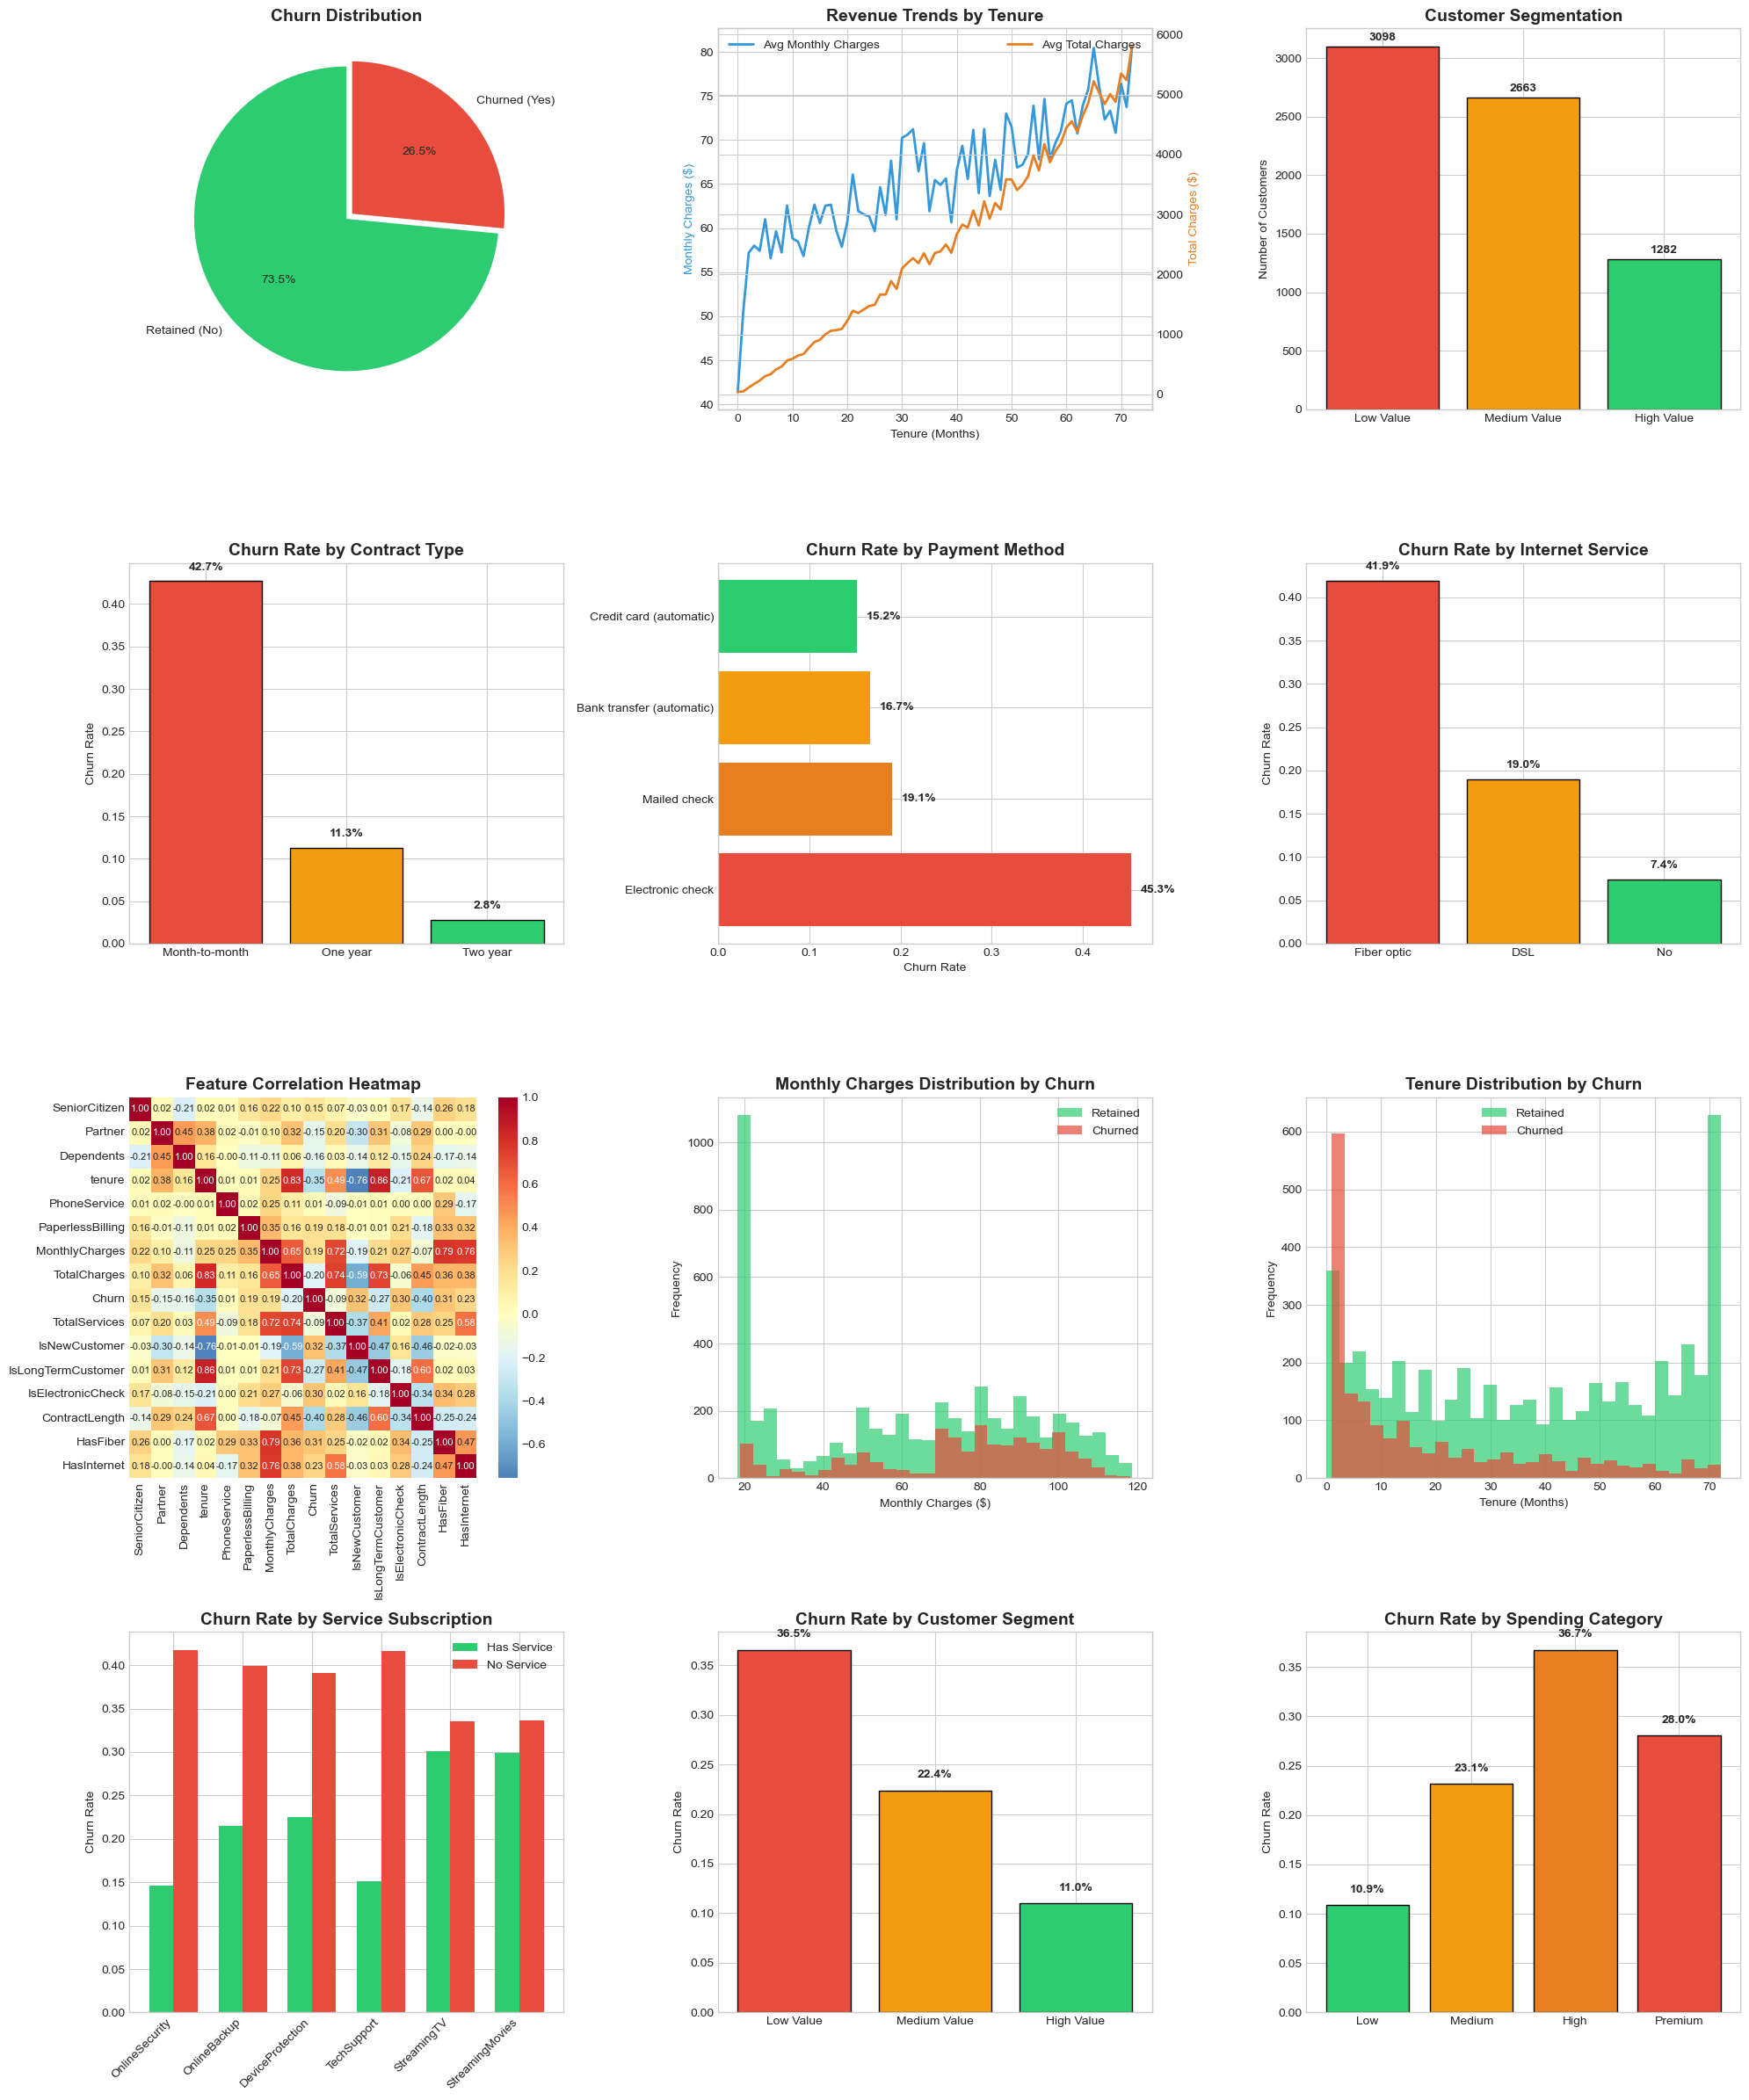

In [17]:
fig = plt.figure(figsize=(20, 24))

# 1. Churn Distribution
ax1 = plt.subplot(4, 3, 1)
churn_counts = df['Churn'].value_counts()
colors = ['#2ecc71', '#e74c3c']
labels = ['Retained (No)', 'Churned (Yes)']
ax1.pie(churn_counts, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90, explode=[0, 0.05])
ax1.set_title('Churn Distribution', fontsize=14, fontweight='bold')

# 2. Revenue Trends by Tenure
ax2 = plt.subplot(4, 3, 2)
tenure_revenue = df.groupby('tenure').agg({'MonthlyCharges': 'mean', 'TotalCharges': 'mean'}).reset_index()
ax2.plot(tenure_revenue['tenure'], tenure_revenue['MonthlyCharges'], label='Avg Monthly Charges', color='#3498db', linewidth=2)
ax2_twin = ax2.twinx()
ax2_twin.plot(tenure_revenue['tenure'], tenure_revenue['TotalCharges'], label='Avg Total Charges', color='#e67e22', linewidth=2)
ax2.set_xlabel('Tenure (Months)')
ax2.set_ylabel('Monthly Charges ($)', color='#3498db')
ax2_twin.set_ylabel('Total Charges ($)', color='#e67e22')
ax2.set_title('Revenue Trends by Tenure', fontsize=14, fontweight='bold')
ax2.legend(loc='upper left')
ax2_twin.legend(loc='upper right')

# 3. Customer Segmentation
ax3 = plt.subplot(4, 3, 3)
segment_counts = df_features['CustomerSegment'].value_counts()
segment_colors = ['#e74c3c', '#f39c12', '#2ecc71']
ax3.bar(segment_counts.index, segment_counts.values, color=segment_colors, edgecolor='black')
ax3.set_title('Customer Segmentation', fontsize=14, fontweight='bold')
ax3.set_ylabel('Number of Customers')
for i, v in enumerate(segment_counts.values):
    ax3.text(i, v + 50, str(v), ha='center', fontweight='bold')

# 4. Churn by Contract Type
ax4 = plt.subplot(4, 3, 4)
contract_churn = df.groupby('Contract')['Churn'].mean().sort_values(ascending=False)
bars = ax4.bar(contract_churn.index, contract_churn.values, color=['#e74c3c', '#f39c12', '#2ecc71'], edgecolor='black')
ax4.set_title('Churn Rate by Contract Type', fontsize=14, fontweight='bold')
ax4.set_ylabel('Churn Rate')
for bar in bars:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height + 0.01, f'{height:.1%}', ha='center', va='bottom', fontweight='bold')

# 5. Churn by Payment Method
ax5 = plt.subplot(4, 3, 5)
payment_churn = df.groupby('PaymentMethod')['Churn'].mean().sort_values(ascending=False)
bars = ax5.barh(payment_churn.index, payment_churn.values, color=['#e74c3c', '#e67e22', '#f39c12', '#2ecc71'])
ax5.set_title('Churn Rate by Payment Method', fontsize=14, fontweight='bold')
ax5.set_xlabel('Churn Rate')
for i, v in enumerate(payment_churn.values):
    ax5.text(v + 0.01, i, f'{v:.1%}', va='center', fontweight='bold')

# 6. Churn by Internet Service
ax6 = plt.subplot(4, 3, 6)
internet_churn = df.groupby('InternetService')['Churn'].mean().sort_values(ascending=False)
bars = ax6.bar(internet_churn.index, internet_churn.values, color=['#e74c3c', '#f39c12', '#2ecc71'], edgecolor='black')
ax6.set_title('Churn Rate by Internet Service', fontsize=14, fontweight='bold')
ax6.set_ylabel('Churn Rate')
for bar in bars:
    height = bar.get_height()
    ax6.text(bar.get_x() + bar.get_width()/2., height + 0.01, f'{height:.1%}', ha='center', va='bottom', fontweight='bold')

# 7. Correlation Heatmap
ax7 = plt.subplot(4, 3, 7)
corr_cols = ['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 
             'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn',
             'TotalServices', 'IsNewCustomer', 'IsLongTermCustomer', 'IsElectronicCheck',
             'ContractLength', 'HasFiber', 'HasInternet']
corr_matrix = df_features[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlBu_r', center=0, ax=ax7, annot_kws={'size': 8})
ax7.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')

# 8. Monthly Charges Distribution by Churn
ax8 = plt.subplot(4, 3, 8)
df[df['Churn']==0]['MonthlyCharges'].hist(bins=30, alpha=0.7, label='Retained', color='#2ecc71', ax=ax8)
df[df['Churn']==1]['MonthlyCharges'].hist(bins=30, alpha=0.7, label='Churned', color='#e74c3c', ax=ax8)
ax8.set_title('Monthly Charges Distribution by Churn', fontsize=14, fontweight='bold')
ax8.set_xlabel('Monthly Charges ($)')
ax8.set_ylabel('Frequency')
ax8.legend()

# 9. Tenure Distribution by Churn
ax9 = plt.subplot(4, 3, 9)
df[df['Churn']==0]['tenure'].hist(bins=30, alpha=0.7, label='Retained', color='#2ecc71', ax=ax9)
df[df['Churn']==1]['tenure'].hist(bins=30, alpha=0.7, label='Churned', color='#e74c3c', ax=ax9)
ax9.set_title('Tenure Distribution by Churn', fontsize=14, fontweight='bold')
ax9.set_xlabel('Tenure (Months)')
ax9.set_ylabel('Frequency')
ax9.legend()

# 10. Service Subscription Comparison
ax10 = plt.subplot(4, 3, 10)
service_churn = []
service_names = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
for service in service_names:
    yes_churn = df[df[service] == 'Yes']['Churn'].mean()
    no_churn = df[df[service] == 'No']['Churn'].mean()
    service_churn.append([yes_churn, no_churn])

x = np.arange(len(service_names))
width = 0.35
bars1 = ax10.bar(x - width/2, [s[0] for s in service_churn], width, label='Has Service', color='#2ecc71')
bars2 = ax10.bar(x + width/2, [s[1] for s in service_churn], width, label='No Service', color='#e74c3c')
ax10.set_title('Churn Rate by Service Subscription', fontsize=14, fontweight='bold')
ax10.set_ylabel('Churn Rate')
ax10.set_xticks(x)
ax10.set_xticklabels(service_names, rotation=45, ha='right')
ax10.legend()

# 11. Segment-wise Churn Rate
ax11 = plt.subplot(4, 3, 11)
segment_churn_rate = df_features.groupby('CustomerSegment')['Churn'].mean()
bars = ax11.bar(segment_churn_rate.index, segment_churn_rate.values, color=['#e74c3c', '#f39c12', '#2ecc71'], edgecolor='black')
ax11.set_title('Churn Rate by Customer Segment', fontsize=14, fontweight='bold')
ax11.set_ylabel('Churn Rate')
for bar in bars:
    height = bar.get_height()
    ax11.text(bar.get_x() + bar.get_width()/2., height + 0.01, f'{height:.1%}', ha='center', va='bottom', fontweight='bold')

# 12. Spending Category vs Churn
ax12 = plt.subplot(4, 3, 12)
spending_churn = df_features.groupby('SpendingCategory')['Churn'].mean()
bars = ax12.bar(spending_churn.index, spending_churn.values, color=['#2ecc71', '#f39c12', '#e67e22', '#e74c3c'], edgecolor='black')
ax12.set_title('Churn Rate by Spending Category', fontsize=14, fontweight='bold')
ax12.set_ylabel('Churn Rate')
for bar in bars:
    height = bar.get_height()
    ax12.text(bar.get_x() + bar.get_width()/2., height + 0.01, f'{height:.1%}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('visualizations_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

# 5: Machine Learning Models

In [18]:
feature_cols = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
    'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges',
    'TotalServices', 'IsNewCustomer', 'IsLongTermCustomer', 'IsElectronicCheck',
    'ContractLength', 'HasTechSupport', 'HasSecurity', 'SupportScore',
    'RevenueTrend', 'CLV_Proxy', 'HasInternet', 'HasFiber', 'HasMultipleLines',
    'SeniorWithPartner', 'AvgMonthlySpend'
]

categorical_features = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                         'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                         'Contract', 'PaymentMethod']

X = df_features.copy()
le_dict = {}
for col in categorical_features:
    le = LabelEncoder()
    X[col + '_encoded'] = le.fit_transform(X[col].astype(str))
    le_dict[col] = le

encoded_features = [col + '_encoded' for col in categorical_features]
all_features = feature_cols + encoded_features
X = X[all_features]
y = df_features['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model 1: Logistic Regression
lr_model = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)
lr_pred_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

lr_metrics = {
    'Accuracy': accuracy_score(y_test, lr_pred),
    'Precision': precision_score(y_test, lr_pred),
    'Recall': recall_score(y_test, lr_pred),
    'F1 Score': f1_score(y_test, lr_pred),
    'ROC-AUC': roc_auc_score(y_test, lr_pred_proba)
}

print("\nLogistic Regression Metrics:")
for metric, value in lr_metrics.items():
    print(f"  {metric}: {value:.4f}")

# Model 2: Random Forest
rf_model = RandomForestClassifier(n_estimators=200, max_depth=15, min_samples_split=5,
                                   random_state=42, class_weight='balanced', n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_pred_proba = rf_model.predict_proba(X_test)[:, 1]

rf_metrics = {
    'Accuracy': accuracy_score(y_test, rf_pred),
    'Precision': precision_score(y_test, rf_pred),
    'Recall': recall_score(y_test, rf_pred),
    'F1 Score': f1_score(y_test, rf_pred),
    'ROC-AUC': roc_auc_score(y_test, rf_pred_proba)
}

print("\nRandom Forest Metrics:")
for metric, value in rf_metrics.items():
    print(f"  {metric}: {value:.4f}")


Logistic Regression Metrics:
  Accuracy: 0.7445
  Precision: 0.5122
  Recall: 0.7834
  F1 Score: 0.6195
  ROC-AUC: 0.8462

Random Forest Metrics:
  Accuracy: 0.7842
  Precision: 0.5888
  Recall: 0.6203
  F1 Score: 0.6042
  ROC-AUC: 0.8352


# 6: Model Evaluation Visualizations

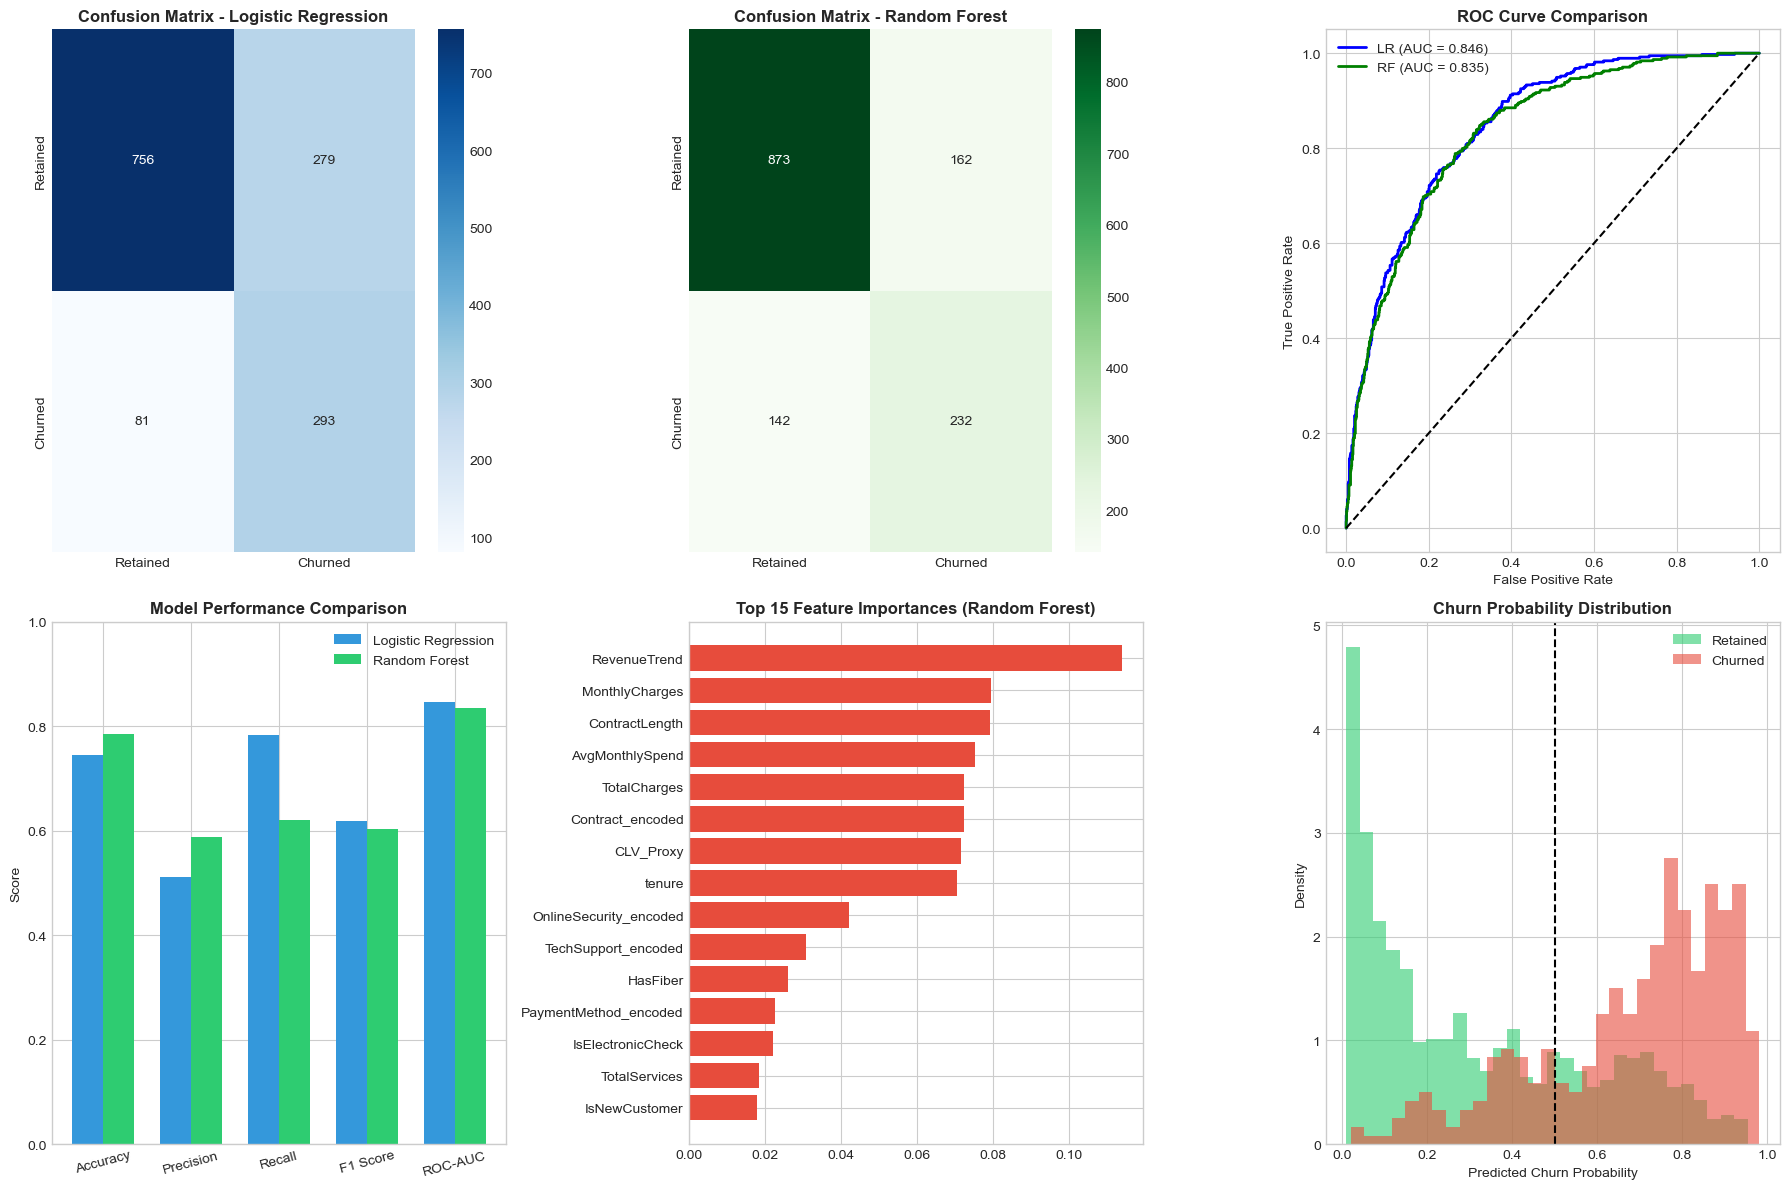

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Confusion Matrix - Logistic Regression
ax1 = axes[0, 0]
cm_lr = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Retained', 'Churned'], yticklabels=['Retained', 'Churned'])
ax1.set_title('Confusion Matrix - Logistic Regression', fontsize=12, fontweight='bold')

# Confusion Matrix - Random Forest
ax2 = axes[0, 1]
cm_rf = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=ax2,
            xticklabels=['Retained', 'Churned'], yticklabels=['Retained', 'Churned'])
ax2.set_title('Confusion Matrix - Random Forest', fontsize=12, fontweight='bold')

# ROC Curve Comparison
ax3 = axes[0, 2]
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_pred_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_pred_proba)
ax3.plot(fpr_lr, tpr_lr, label=f'LR (AUC = {lr_metrics["ROC-AUC"]:.3f})', color='blue', linewidth=2)
ax3.plot(fpr_rf, tpr_rf, label=f'RF (AUC = {rf_metrics["ROC-AUC"]:.3f})', color='green', linewidth=2)
ax3.plot([0, 1], [0, 1], 'k--')
ax3.set_xlabel('False Positive Rate')
ax3.set_ylabel('True Positive Rate')
ax3.set_title('ROC Curve Comparison', fontsize=12, fontweight='bold')
ax3.legend()

# Metrics Comparison
ax4 = axes[1, 0]
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
lr_values = [lr_metrics[m] for m in metrics_names]
rf_values = [rf_metrics[m] for m in metrics_names]
x = np.arange(len(metrics_names))
width = 0.35
ax4.bar(x - width/2, lr_values, width, label='Logistic Regression', color='#3498db')
ax4.bar(x + width/2, rf_values, width, label='Random Forest', color='#2ecc71')
ax4.set_ylabel('Score')
ax4.set_title('Model Performance Comparison', fontsize=12, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(metrics_names, rotation=15)
ax4.legend()
ax4.set_ylim(0, 1)

# Feature Importance
ax5 = axes[1, 1]
feature_importance = pd.DataFrame({
    'feature': all_features,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False).head(15)
ax5.barh(feature_importance['feature'][::-1], feature_importance['importance'][::-1], color='#e74c3c')
ax5.set_title('Top 15 Feature Importances (Random Forest)', fontsize=12, fontweight='bold')

# Probability Distribution
ax6 = axes[1, 2]
ax6.hist(lr_pred_proba[y_test==0], bins=30, alpha=0.6, label='Retained', color='#2ecc71', density=True)
ax6.hist(lr_pred_proba[y_test==1], bins=30, alpha=0.6, label='Churned', color='#e74c3c', density=True)
ax6.set_xlabel('Predicted Churn Probability')
ax6.set_ylabel('Density')
ax6.set_title('Churn Probability Distribution', fontsize=12, fontweight='bold')
ax6.legend()
ax6.axvline(x=0.5, color='black', linestyle='--')

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()

# 7: Prediction System

In [20]:
df_features['ChurnProbability'] = rf_model.predict_proba(X)[:, 1]

def assign_risk_category(prob):
    if prob >= 0.7:
        return 'High Risk'
    elif prob >= 0.4:
        return 'Medium Risk'
    else:
        return 'Low Risk'

df_features['RiskCategory'] = df_features['ChurnProbability'].apply(assign_risk_category)

print("Risk Category Distribution:")
print(df_features['RiskCategory'].value_counts())

print("\nRisk Category vs Actual Churn:")
risk_churn = df_features.groupby('RiskCategory')['Churn'].agg(['count', 'sum', 'mean'])
risk_churn.columns = ['Total', 'Churned', 'Actual_Churn_Rate']
print(risk_churn)

print("\nSample Predictions (First 10 customers):")
sample = df_features[['customerID', 'ChurnProbability', 'RiskCategory', 'Churn']].head(10)
print(sample.to_string(index=False))

Risk Category Distribution:
RiskCategory
Low Risk       4645
High Risk      1247
Medium Risk    1151
Name: count, dtype: int64

Risk Category vs Actual Churn:
              Total  Churned  Actual_Churn_Rate
RiskCategory                                   
High Risk      1247     1183           0.948677
Low Risk       4645      106           0.022820
Medium Risk    1151      580           0.503910

Sample Predictions (First 10 customers):
customerID  ChurnProbability RiskCategory  Churn
7590-VHVEG          0.520072  Medium Risk      0
5575-GNVDE          0.010717     Low Risk      0
3668-QPYBK          0.830292    High Risk      1
7795-CFOCW          0.034159     Low Risk      0
9237-HQITU          0.791819    High Risk      1
9305-CDSKC          0.964840    High Risk      1
1452-KIOVK          0.620306  Medium Risk      0
6713-OKOMC          0.178050     Low Risk      0
7892-POOKP          0.776711    High Risk      1
6388-TABGU          0.057183     Low Risk      0


# 8: Business Insights Report

In [21]:
print("=" * 60)
print("BUSINESS INSIGHTS REPORT")
print("=" * 60)

churned_customers = df_features[df_features['Churn'] == 1]
high_risk = df_features[df_features['RiskCategory'] == 'High Risk']

print("\n1. TOP CHURN REASONS:")
print(f"   - Month-to-month contracts: {df[df['Contract']=='Month-to-month']['Churn'].mean():.1%} churn rate")
print(f"   - Electronic check payment: {df[df['PaymentMethod']=='Electronic check']['Churn'].mean():.1%} churn rate")
print(f"   - Fiber optic internet: {df[df['InternetService']=='Fiber optic']['Churn'].mean():.1%} churn rate")
print(f"   - New customers (0-12 months): {df[df['tenure']<=12]['Churn'].mean():.1%} churn rate")
print(f"   - No tech support: {df[df['TechSupport']=='No']['Churn'].mean():.1%} churn rate")
print(f"   - No online security: {df[df['OnlineSecurity']=='No']['Churn'].mean():.1%} churn rate")

print("\n2. HIGH-RISK CUSTOMER TRAITS:")
print(f"   - Average tenure: {high_risk['tenure'].mean():.1f} months")
print(f"   - Average monthly charges: ${high_risk['MonthlyCharges'].mean():.2f}")
print(f"   - {(high_risk['IsMonthToMonth']==1).mean():.1%} on month-to-month contracts")
print(f"   - {(high_risk['IsElectronicCheck']==1).mean():.1%} use electronic check")
print(f"   - {(high_risk['HasFiber']==1).mean():.1%} have fiber optic")
print(f"   - {(high_risk['HasTechSupport']==0).mean():.1%} have no tech support")
print(f"   - {(high_risk['HasSecurity']==0).mean():.1%} have no online security")

print("\n3. REVENUE IMPACT ESTIMATION:")
total_monthly = df['MonthlyCharges'].sum()
high_risk_monthly = high_risk['MonthlyCharges'].sum()
print(f"   - Total monthly revenue: ${total_monthly:,.2f}")
print(f"   - High-risk monthly revenue: ${high_risk_monthly:,.2f}")
print(f"   - Revenue at risk: {high_risk_monthly/total_monthly*100:.1f}%")
print(f"   - Potential annual loss: ${high_risk_monthly*12:,.2f}")
print(f"   - 20% churn reduction saves: ${high_risk_monthly*12*0.20:,.2f}")

print("\n4. CUSTOMER SEGMENTATION SUMMARY:")
segment_summary = df_features.groupby('CustomerSegment').agg({
    'MonthlyCharges': 'mean',
    'TotalCharges': 'mean',
    'tenure': 'mean',
    'Churn': 'mean',
    'TotalServices': 'mean'
}).round(2)
print(segment_summary)

print("\n" + "=" * 60)
print("TASK COMPLETED SUCCESSFULLY!")
print("=" * 60)

BUSINESS INSIGHTS REPORT

1. TOP CHURN REASONS:
   - Month-to-month contracts: 42.7% churn rate
   - Electronic check payment: 45.3% churn rate
   - Fiber optic internet: 41.9% churn rate
   - New customers (0-12 months): 47.4% churn rate
   - No tech support: 41.6% churn rate
   - No online security: 41.8% churn rate

2. HIGH-RISK CUSTOMER TRAITS:
   - Average tenure: 11.3 months
   - Average monthly charges: $77.56
   - 99.2% on month-to-month contracts
   - 68.3% use electronic check
   - 80.5% have fiber optic
   - 90.5% have no tech support
   - 92.1% have no online security

3. REVENUE IMPACT ESTIMATION:
   - Total monthly revenue: $456,116.60
   - High-risk monthly revenue: $96,719.30
   - Revenue at risk: 21.2%
   - Potential annual loss: $1,160,631.60
   - 20% churn reduction saves: $232,126.32

4. CUSTOMER SEGMENTATION SUMMARY:
                 MonthlyCharges  TotalCharges  tenure  Churn  TotalServices
CustomerSegment                                                           